In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
file = '../data/training_data.csv'

df = pd.read_csv(file, skiprows=13) # 13 rows are skipped because the NASA POWER API's first 
                                    # 13 rows are metadata about the dataset therefore skipped
# display(df.head()) # Initial DataFrame

df = df.rename(columns={'ALLSKY_SFC_SW_DWN' : 'GHI(W/m2)' , 'WSC' : 'Windspeed(m/s)'}) # Renamed to simpler names with their units

# Renaming to datetime object instead of using 3 diff rows
time_column = df[['YEAR' , 'MO' , 'DY' , 'HR']].rename(columns={'YEAR' : 'year' , 'MO' : 'month' , 'DY' : 'day' , 'HR' : 'hour'}) 
df['Time'] = pd.to_datetime(time_column)
df = df.set_index('Time')
df = df.drop(columns=['YEAR' , 'MO' , 'DY' , 'HR'])

print("Missing Values:")
print(df.isnull().sum())

print(df.agg(['min' , 'max' , 'mean'])) # checking ranges for our rows to spot boundaries and any invalid values


Missing Values:
GHI(W/m2)         0
Windspeed(m/s)    0
dtype: int64
       GHI(W/m2)  Windspeed(m/s)
min      0.00000        0.020000
max   1059.72000       22.850000
mean   227.77889        7.053288


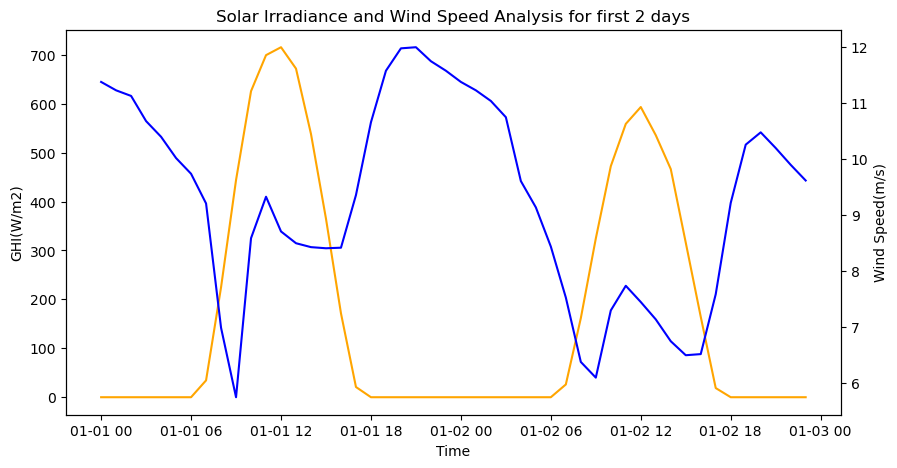

In [97]:
two_days = df.loc['2014-01-01' : '2014-01-02']

fig,ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(two_days.index, two_days['GHI(W/m2)'], color='orange') # GHI plotted on left y-axis
ax1.set(ylabel='GHI(W/m2)' , xlabel='Time')

ax2 = ax1.twinx() # Creating the 2nd y-axis which shares x-axis
ax2.plot(two_days.index, two_days['Windspeed(m/s)'], color='blue') # Wind Speed plotted on right y-axis
ax2.set(ylabel='Wind Speed(m/s)')

plt.title('Solar Irradiance and Wind Speed Analysis for first 2 days')
plt.show()

In [131]:
## Hybrid Plant Power Calculation

# Plant Capacities
sol_AC_cap_MWh = 20
sol_DC_cap_MWh = 25
wind_cap_MWh = 10
battery_cap_MWh = 25

sol_PR = 0.78 # Performance Ratio for Solar

sol_DC_output = sol_DC_cap_MWh * (df['GHI(W/m2)'] / 1000) * solar_PR
df['Solar Energy(MWh)'] = sol_DC_output.clip(upper=sol_AC_cap_MWh) # Inverter clipping

velo = df['Windspeed(m/s)']

# Defining boundaries for calculation of wind energy
wind_energy_rules = [(velo < 3), (velo >= 3) & (velo < 12),    
                     (12 >= velo) & (velo <= 25), (velo > 25)] 
wind_energy_results = [0 , wind_cap_MWh * ((velo / 12) ** 3), # below 3(m/s) very slow and above 25 dangerous
                       wind_cap_MWh , 0]                      # therefore at those they are fixed to 0

df['Wind Energy(MWh)'] = np.select(wind_energy_rules, wind_energy_results, default=0)

df['Total Energy(MWh)'] = df['Solar Energy(MW)'] + df['Wind Energy(MW)']

df[['Windspeed(m/s)' , 'Wind Energy(MWh)' , 'GHI(W/m2)' , 'Solar Energy(MWh)']].head(10).round(3)

,Windspeed(m/s),Wind Energy(MWh),GHI(W/m2),Solar Energy(MWh)
Time,,,,
2014-01-01 00:00:00,11.37,8.506,0.00,0.000
2014-01-01 01:00:00,11.22,8.174,0.00,0.000
2014-01-01 02:00:00,11.12,7.957,0.00,0.000
2014-01-01 03:00:00,10.67,7.030,0.00,0.000
2014-01-01 04:00:00,10.39,6.491,0.00,0.000
2014-01-01 05:00:00,10.01,5.804,0.00,0.000
2014-01-01 06:00:00,9.73,5.331,0.00,0.000
2014-01-01 07:00:00,9.20,4.506,34.42,0.671
2014-01-01 08:00:00,6.98,1.968,224.75,4.383


In [130]:
## Battery charging and storing Logic

electrolyzer_MW = 9.5
electrolyzer_safe_MW = 0.4 * electrolyzer_MW # Below 40% electrolyzers can be hazardous due to gas mixing

total_energy = df['Total Energy(MWh)'].to_numpy()
battery_charge = np.zeros(len(df))
cumu = np.zeros(len(df))

for i in range(len(df) - 1):
    energy = total_energy[i + 1]
    p_cumu = cumu[i]
    
    charge = 0
    if energy < electrolyzer_safe_MW: # Low power redirect it to battery
        gap = electrolyzer_safe_MW - energy
        
        if p_cumu < gap:
            charge = energy
            
    elif energy >  electrolyzer_MW: # High power which exceeds max electrolyzer cap and check leftover energy in battery
        excess = energy - electrolyzer_MW
        left = battery_cap_MWh - p_cumu

        charge = min(left, excess)

    battery_charge[i + 1] = charge
    cumu[i + 1] = p_cumu + charge

            
df['Battery_Charge(MW)'] = battery_charge
df['Stored Energy'] = cumu

df[['Total Energy(MWh)' , 'Battery_Charge(MW)' , 'Stored Energy']].head(14).round(3)

,Total Energy(MWh),Battery_Charge(MW),Stored Energy
Time,,,
2014-01-01 00:00:00,8.506,0.000,0.000
2014-01-01 01:00:00,8.174,0.000,0.000
2014-01-01 02:00:00,7.957,0.000,0.000
2014-01-01 03:00:00,7.030,0.000,0.000
2014-01-01 04:00:00,6.491,0.000,0.000
2014-01-01 05:00:00,5.804,0.000,0.000
2014-01-01 06:00:00,5.331,0.000,0.000
2014-01-01 07:00:00,5.177,0.000,0.000
2014-01-01 08:00:00,6.351,0.000,0.000
